# Xanadu Spectral Methods Paper Experiments

## Objective Function

For a training multiset $\mathcal{X}$ of bitstrings $x \in \{0,1\}^n$, the post defines the smoothness energy

$$
\mathcal{E}(p)
= \frac{1}{2^n}\sum_{x \in \{0,1\}^n}\sum_{i=1}^n
\left(p(x)-p(x\oplus e_i)\right)^2.
$$

The optimization problem is

$$
\begin{aligned}
\min_p \quad & -\left[\sum_{x \in \mathcal{X}}\log p(x) - \lambda \mathcal{E}(p)\right] \\
\text{s.t.}\quad & p(x) \ge 0, \\
& \sum_{x \in \{0,1\}^n}p(x)=1.
\end{aligned}
$$

Equivalently, using counts $c_x$ for the training multiset,

$$
f(p) = -\sum_{x \in \{0,1\}^n} c_x \log p_x + \lambda \mathcal{E}(p),
\qquad p \in \Delta_{2^n}.
$$


## Concrete Problem Experiment

Use three-bit strings, so the probability vector has $2^3=8$ entries. The observed training multiset is summarized by the following counts:

$$
\begin{array}{c|cccccccc}
x & 000 & 001 & 010 & 011 & 100 & 101 & 110 & 111 \\
\hline
c_x & 10 & 6 & 5 & 0 & 5 & 0 & 0 & 2
\end{array}
$$

The unregularized empirical distribution assigns zero mass to the unobserved strings. The spectral smoothness term should instead spread some mass to Hamming-neighboring strings. We solve the constrained convex problem with the Frank-Wolfe algorithm on the simplex, starting from the simplest strictly positive state:

$$
p^{(0)}(x)=\frac{1}{8}\quad\text{for every }x\in\{0,1\}^3.
$$


In [21]:
import sys
import matplotlib.pyplot as plt
import numpy as np

print(sys.executable)
assert "/.venv/" in sys.executable or sys.executable.endswith("/.venv/bin/python")

n = 3
labels = [format(i, f"0{n}b") for i in range(2**n)]
counts_by_label = {"000": 10, "001": 6, "010": 5, "100": 5, "111": 2}
counts = np.array([counts_by_label.get(label, 0) for label in labels], dtype=float)
empirical = counts / counts.sum()
lam = 200.0
p0 = np.ones(2**n) / (2**n)

print(f"n = {n}, states = {len(labels)}, samples = {int(counts.sum())}, lambda = {lam:g}")
print(f"initial p min = {p0.min():.6f}, sum = {p0.sum():.6f}")


/home/lukas/Desktop/Gitrepos/LukasLatentSpace/.venv/bin/python
n = 3, states = 8, samples = 28, lambda = 200
initial p min = 0.125000, sum = 1.000000


In [22]:
def smoothness_energy(p, n):
    d = 2**n
    total = 0.0
    for x in range(d):
        for i in range(n):
            total += (p[x] - p[x ^ (1 << i)]) ** 2
    return total / d


def smoothness_gradient(p, n):
    d = 2**n
    grad = np.zeros_like(p)
    for x in range(d):
        for i in range(n):
            y = x ^ (1 << i)
            diff = p[x] - p[y]
            grad[x] += 2.0 * diff / d
            grad[y] -= 2.0 * diff / d
    return grad


def main_objective(p, counts):
    observed = counts > 0
    return -float(np.dot(counts[observed], np.log(p[observed])))


def objective(p, counts, n, lam):
    return main_objective(p, counts) + lam * smoothness_energy(p, n)


def gradient(p, counts, n, lam):
    return -counts / p + lam * smoothness_gradient(p, n)


def simplex_lmo(grad):
    j = int(np.argmin(grad))
    s = np.zeros_like(grad)
    s[j] = 1.0
    return s, j


def line_search(p, direction, counts, n, lam, rounds=50):
    lo, hi = 0.0, 1.0 - 1e-12
    invphi = (5**0.5 - 1) / 2
    x1 = hi - invphi * (hi - lo)
    x2 = lo + invphi * (hi - lo)
    f1 = objective(p + x1 * direction, counts, n, lam)
    f2 = objective(p + x2 * direction, counts, n, lam)

    for _ in range(rounds):
        if f1 > f2:
            lo = x1
            x1, f1 = x2, f2
            x2 = lo + invphi * (hi - lo)
            f2 = objective(p + x2 * direction, counts, n, lam)
        else:
            hi = x2
            x2, f2 = x1, f1
            x1 = hi - invphi * (hi - lo)
            f1 = objective(p + x1 * direction, counts, n, lam)

    return 0.5 * (lo + hi)


def frank_wolfe(counts, n, lam, p0, max_iter=1500, tol=1e-7):
    p = p0.astype(float).copy()
    history = []

    for k in range(max_iter):
        grad = gradient(p, counts, n, lam)
        s, atom = simplex_lmo(grad)
        direction = s - p
        gap = float(np.dot(grad, p - s))
        energy = smoothness_energy(p, n)
        f_value = main_objective(p, counts) + lam * energy
        history.append({"iter": k, "objective": f_value, "smoothness_energy": energy, "gap": gap, "atom": atom, "gamma": 0.0})

        if gap <= tol:
            break

        gamma = line_search(p, direction, counts, n, lam)
        p = p + gamma * direction
        history[-1]["gamma"] = gamma

    return p, history


In [23]:
p_fw, history = frank_wolfe(counts, n, lam, p0)

fw_main = main_objective(p_fw, counts)
fw_energy = smoothness_energy(p_fw, n)
fw_objective = fw_main + lam * fw_energy

empirical_main = main_objective(empirical, counts)
empirical_energy = smoothness_energy(empirical, n)
empirical_objective = empirical_main + lam * empirical_energy

print(f"iterations: {len(history)}")
print(f"final objective: {fw_objective:.9f}")
print(f"final Frank-Wolfe gap: {history[-1]['gap']:.3e}")
print(f"final main objective value: {fw_main:.9f}")
print(f"final smoothness energy: {fw_energy:.9f}")
print(f"empirical objective: {empirical_objective:.9f}")
print(f"empirical main objective value: {empirical_main:.9f}")
print(f"empirical smoothness energy: {empirical_energy:.9f}")
print(f"min p(x): {p_fw.min():.9f}, sum p(x): {p_fw.sum():.9f}")

print("\nobjective comparison")
print("distribution    objective    main objective    smoothness energy")
print(f"{'empirical':>12}  {empirical_objective:>11.6f}  {empirical_main:>14.6f}  {empirical_energy:>17.6f}")
print(f"{'Frank-Wolfe':>12}  {fw_objective:>11.6f}  {fw_main:>14.6f}  {fw_energy:>17.6f}")

print("\nstate  count  empirical   Frank-Wolfe")
for label, count, p_emp, p_hat in zip(labels, counts, empirical, p_fw):
    print(f"{label:>5}  {int(count):>5}  {p_emp:>9.6f}   {p_hat:>11.6f}")


iterations: 1500
final objective: 52.201805131
final Frank-Wolfe gap: 1.268e-05
final main objective value: 48.567148038
final smoothness energy: 0.018173285
empirical objective: 57.988522605
empirical main objective value: 42.044645054
empirical smoothness energy: 0.079719388
min p(x): 0.062984562, sum p(x): 1.000000000

objective comparison
distribution    objective    main objective    smoothness energy
   empirical    57.988523       42.044645           0.079719
 Frank-Wolfe    52.201805       48.567148           0.018173

state  count  empirical   Frank-Wolfe
  000     10   0.357143      0.235103
  001      6   0.214286      0.171054
  010      5   0.178571      0.158107
  011      0   0.000000      0.067300
  100      5   0.178571      0.158107
  101      0   0.000000      0.067300
  110      0   0.000000      0.062985
  111      2   0.071429      0.080045


We can see that the smoothness constraint leads to giving 011 and 101, 110 non-zero probabilities. Compared to just the empirical distribution.

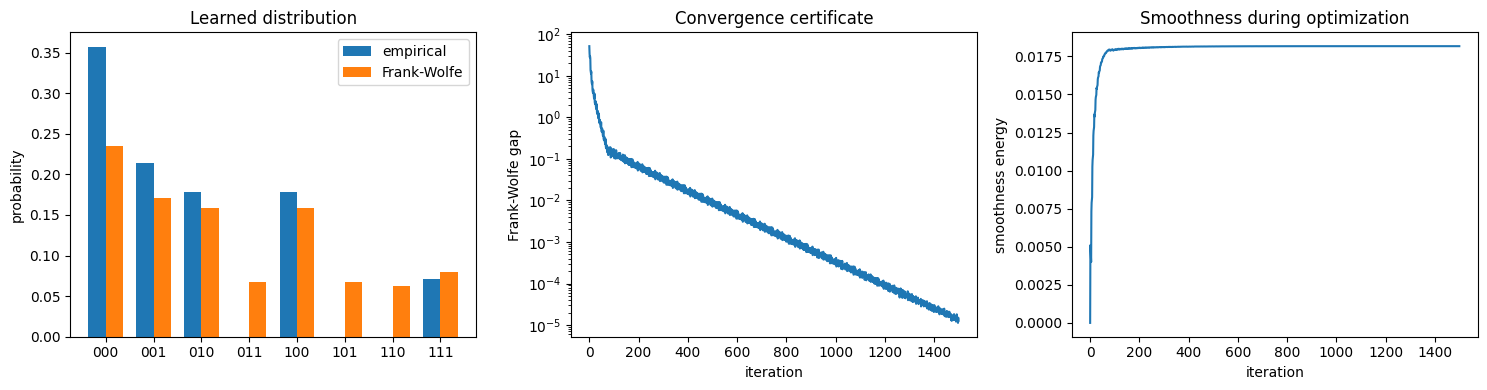

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
positions = np.arange(len(labels))

axes[0].bar(positions - 0.18, empirical, width=0.36, label="empirical")
axes[0].bar(positions + 0.18, p_fw, width=0.36, label="Frank-Wolfe")
axes[0].set_xticks(positions, labels)
axes[0].set_ylabel("probability")
axes[0].set_title("Learned distribution")
axes[0].legend()

axes[1].semilogy([item["gap"] for item in history])
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("Frank-Wolfe gap")
axes[1].set_title("Convergence certificate")

axes[2].plot([item["smoothness_energy"] for item in history])
axes[2].set_xlabel("iteration")
axes[2].set_ylabel("smoothness energy")
axes[2].set_title("Smoothness during optimization")

fig.tight_layout()
